<a href="https://colab.research.google.com/github/peperjet/bc-ml/blob/main/dacon/wine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# 라이브러리 로딩
import pandas as pd
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt


# 경고 메세지 숨기기
import warnings
warnings.filterwarnings('ignore')


In [2]:
# 데이터 불러오기
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

간단한 EDA

In [3]:
# train 데이터의 개형을 살펴봅니다
# index를 제외하면 총 13개 변수를 가집니다.

train.head()

,index,quality,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type
0,0,5,5.6,0.695,0.06,6.8,0.042,9.0,84.0,0.99432,3.44,0.44,10.2,white
1,1,5,8.8,0.610,0.14,2.4,0.067,10.0,42.0,0.99690,3.19,0.59,9.5,red
2,2,5,7.9,0.210,0.39,2.0,0.057,21.0,138.0,0.99176,3.05,0.52,10.9,white
3,3,6,7.0,0.210,0.31,6.0,0.046,29.0,108.0,0.99390,3.26,0.50,10.8,white
4,4,6,7.8,0.400,0.26,9.5,0.059,32.0,178.0,0.99550,3.04,0.43,10.9,white


- index : 구분자
- quality : 품질
- fixed acidity : 산도
- volatile acidity : 휘발성산
- citric acid : 시트르산
- residual sugar 잔당 : 발효 후 와인 속에 남아있는 당분
- chlorides : 염화물
- free sulfur dioxide : 독립 이산화황
- total sulfur dioxide : 총 이산화황
- density : 밀도
- pH : 수소이온농도
- sulphates : 황산염
- alcohol : 도수
- type : 종류



In [4]:
# test 데이터의 개형을 살펴봅니다
# index를 제외하면 총 12개 변수를 가집니다.
# train 중 quality 변수가 사라졌습니다.
test.head()

,index,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type
0,0,9.0,0.31,0.48,6.6,0.043,11.0,73.0,0.99380,2.90,0.38,11.6,white
1,1,13.3,0.43,0.58,1.9,0.070,15.0,40.0,1.00040,3.06,0.49,9.0,red
2,2,6.5,0.28,0.27,5.2,0.040,44.0,179.0,0.99480,3.19,0.69,9.4,white
3,3,7.2,0.15,0.39,1.8,0.043,21.0,159.0,0.99480,3.52,0.47,10.0,white
4,4,6.8,0.26,0.26,2.0,0.019,23.5,72.0,0.99041,3.16,0.47,11.8,white


In [5]:
# tain 데이터의 열 별 정보를 살펴봅니다.
# 결측치는 없습니다
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5497 entries, 0 to 5496
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 5497 non-null   int64  
 1   quality               5497 non-null   int64  
 2   fixed acidity         5497 non-null   float64
 3   volatile acidity      5497 non-null   float64
 4   citric acid           5497 non-null   float64
 5   residual sugar        5497 non-null   float64
 6   chlorides             5497 non-null   float64
 7   free sulfur dioxide   5497 non-null   float64
 8   total sulfur dioxide  5497 non-null   float64
 9   density               5497 non-null   float64
 10  pH                    5497 non-null   float64
 11  sulphates             5497 non-null   float64
 12  alcohol               5497 non-null   float64
 13  type                  5497 non-null   object 
dtypes: float64(11), int64(2), object(1)
memory usage: 601.4+ KB


<Axes: >

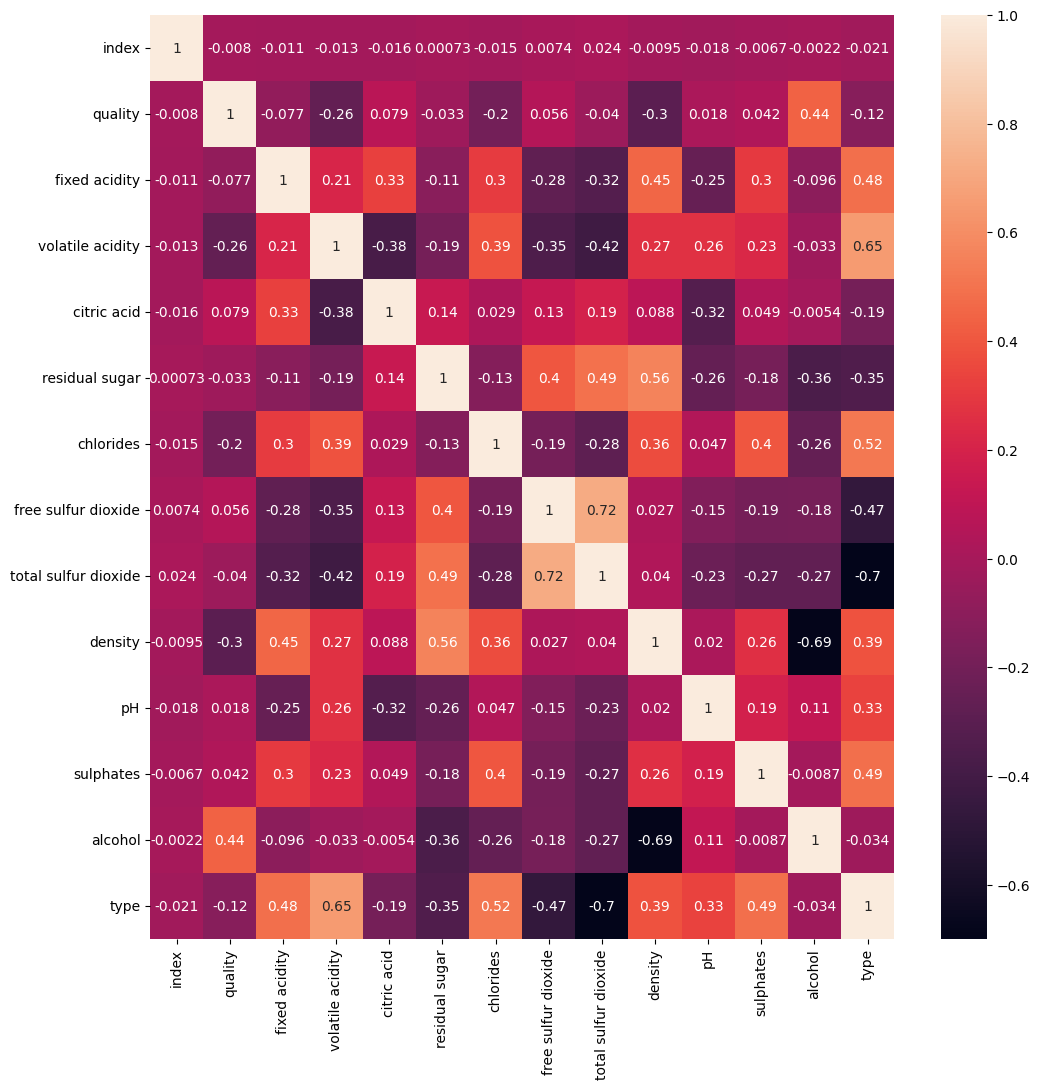

In [7]:
# train의 변수 간 상관관계를 살펴봅니다.
# 'type' 컬럼을 숫자로 변환합니다 (예: white=0, red=1)
train_corr = train.copy()
train_corr['type'] = train_corr['type'].map({'white': 0, 'red': 1})

plt.figure(figsize=(12,12))
sns.heatmap(data = train_corr.corr(), annot=True)

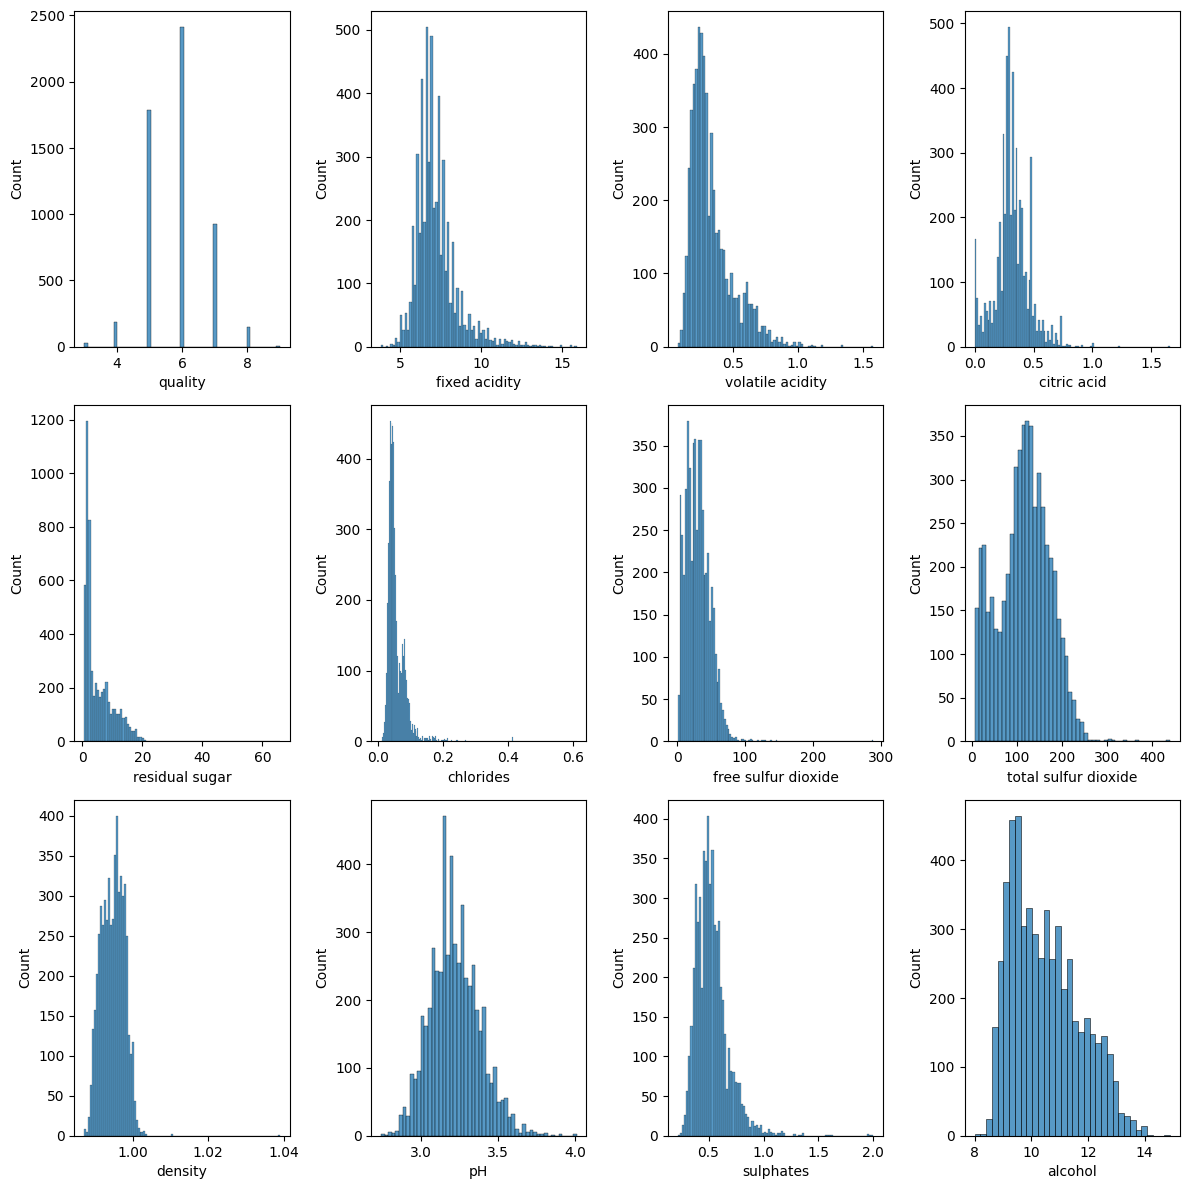

In [11]:
# train의 각 변수별 분포를 살펴보자
plt.figure(figsize=(12,12))
for i in range(1,13):
    plt.subplot(3,4,i)
    sns.histplot(train.iloc[:,i]) # 데이터가 어떻게 퍼져있는지 보여주는 함수

plt.tight_layout()
plt.show()

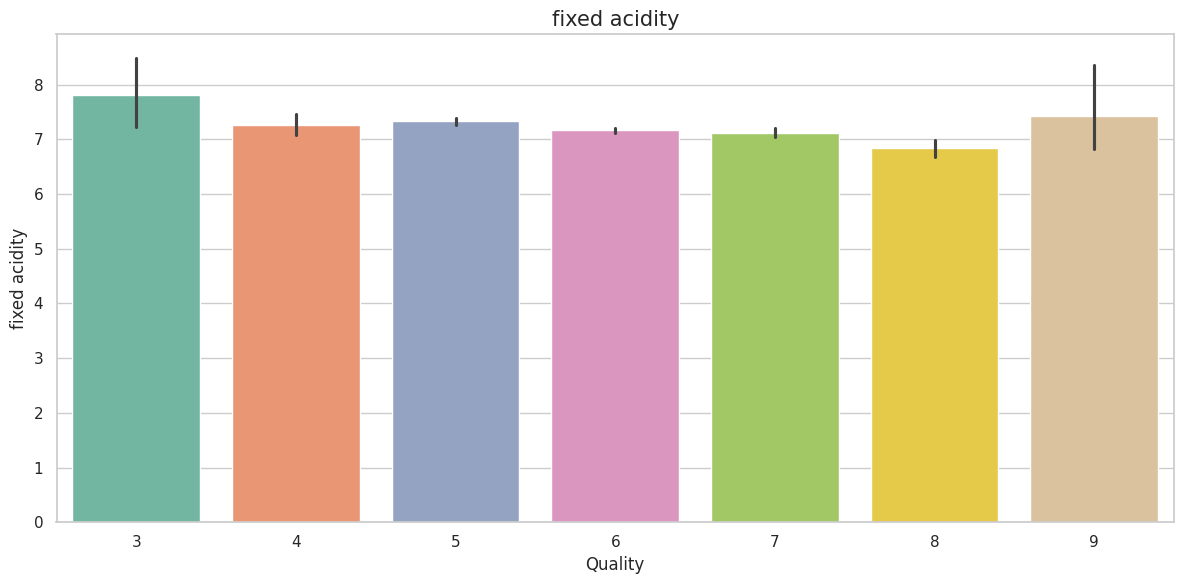

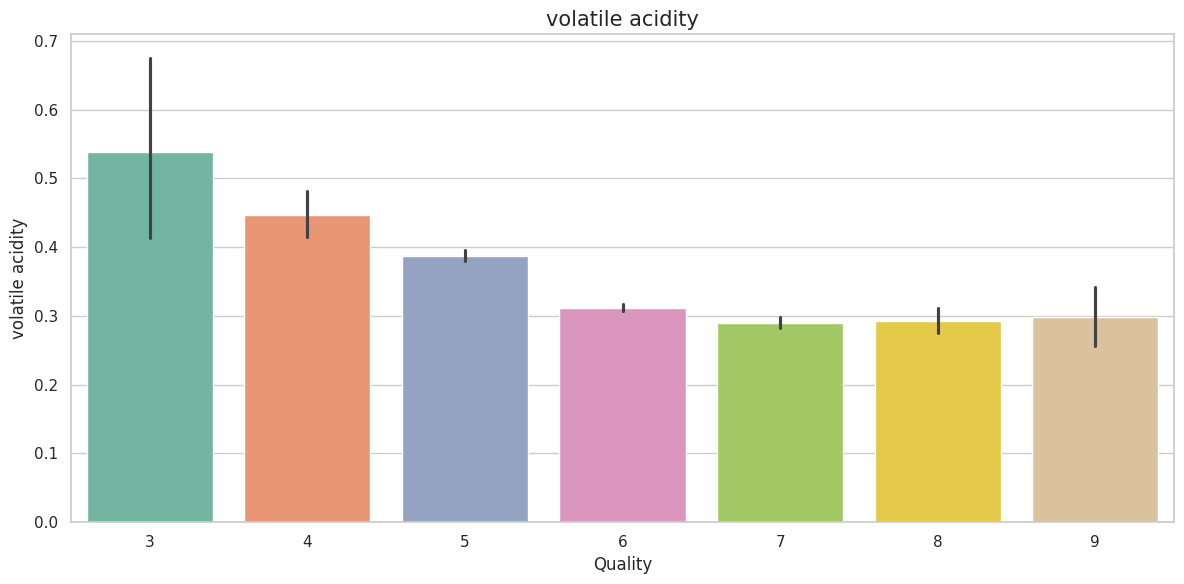

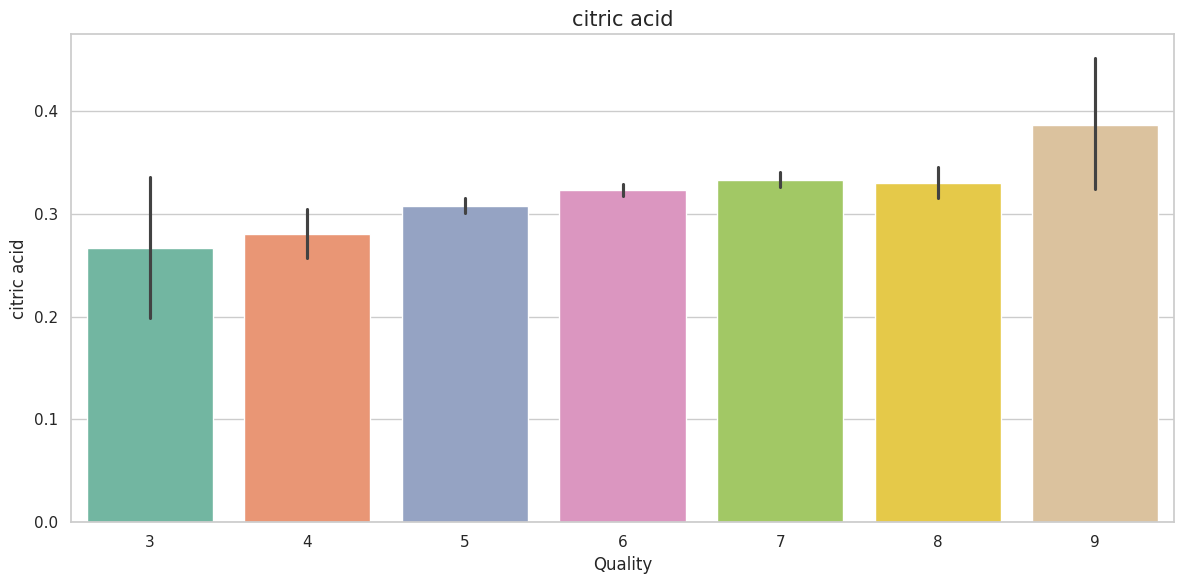

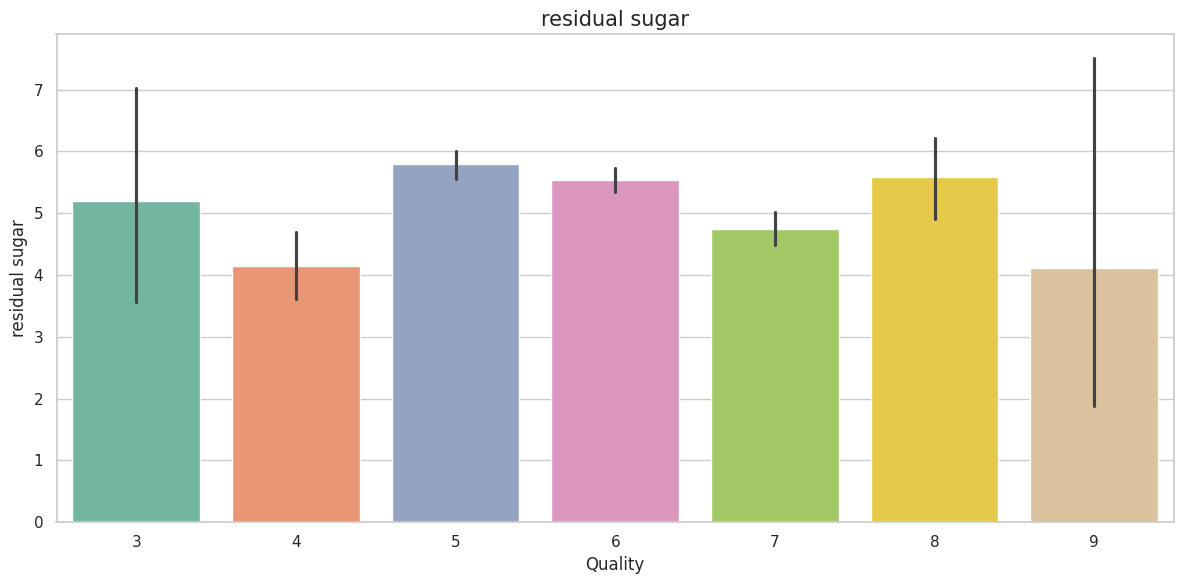

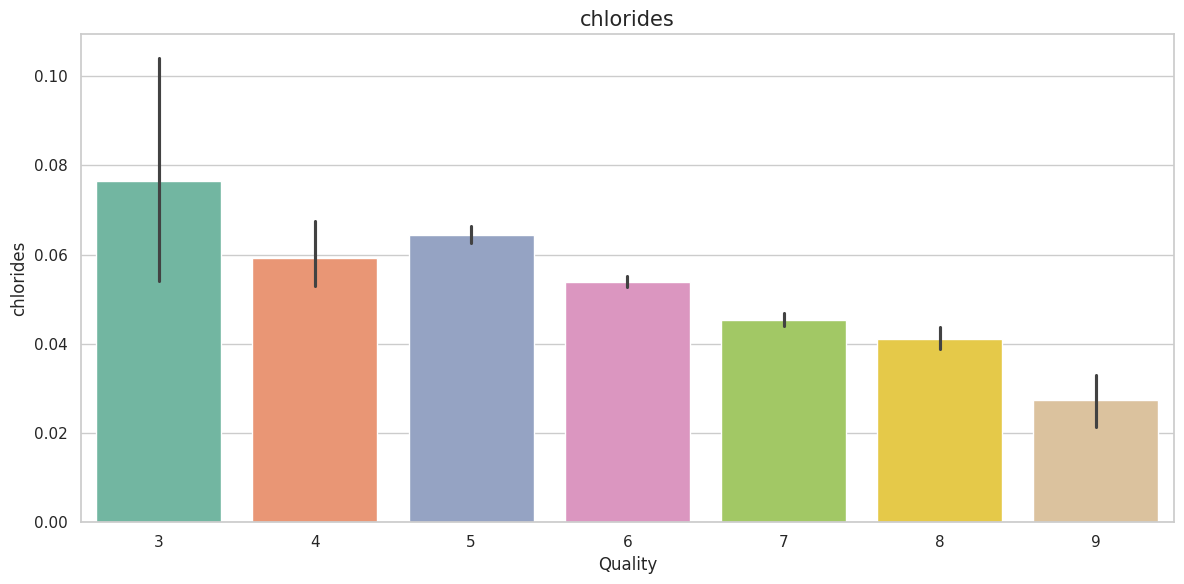

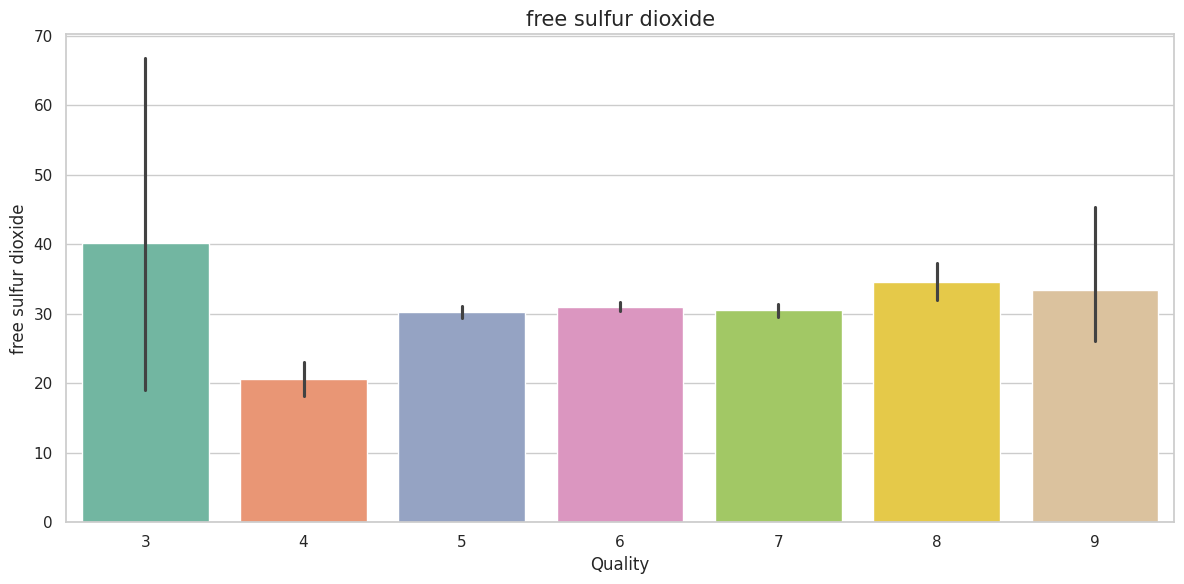

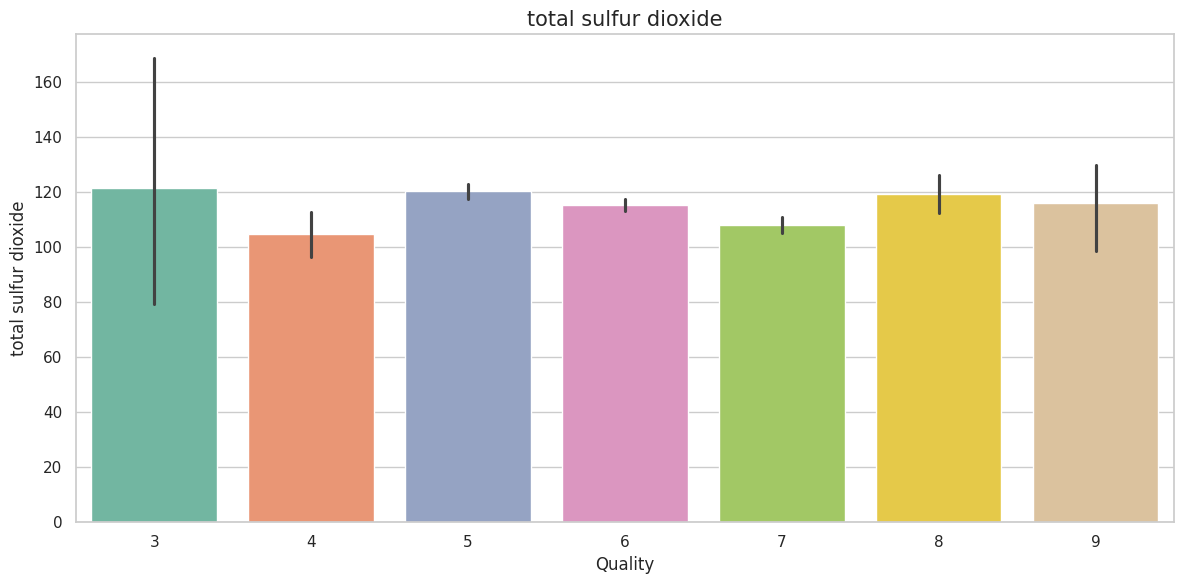

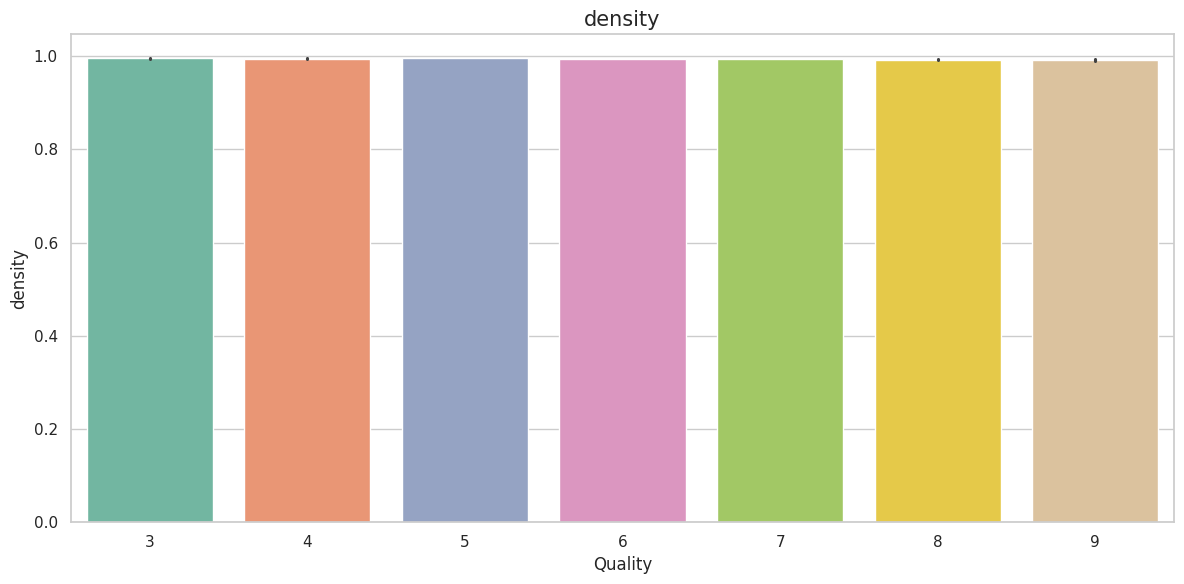

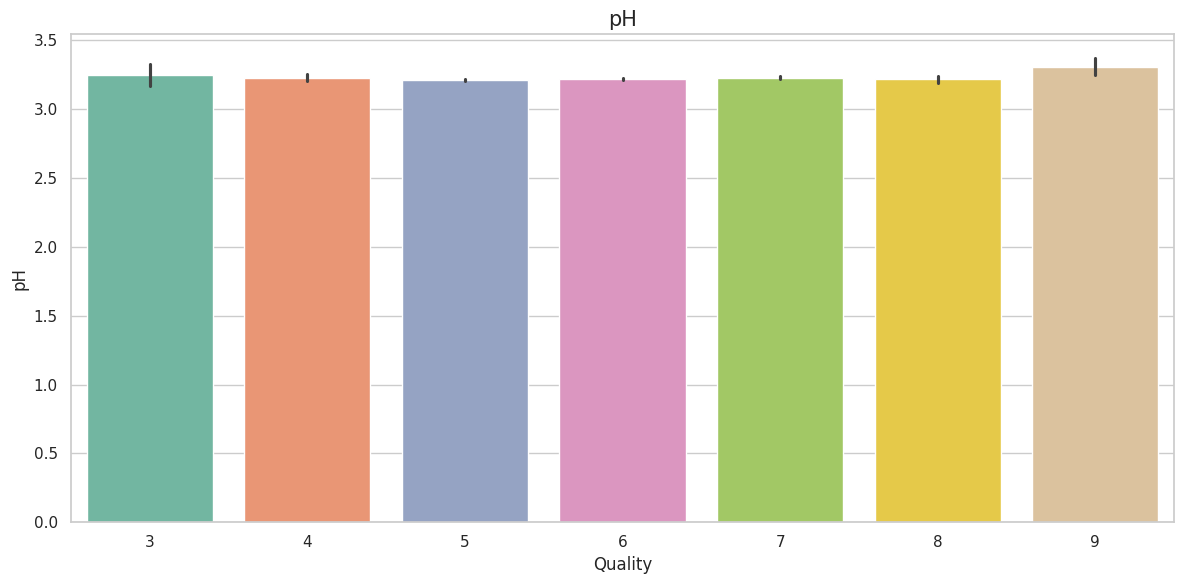

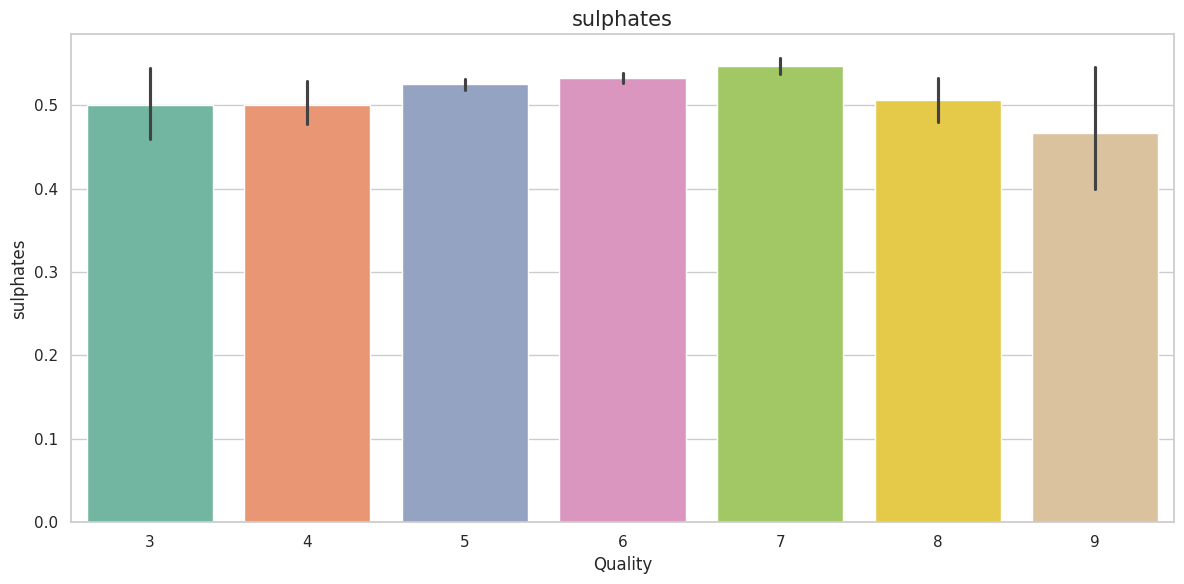

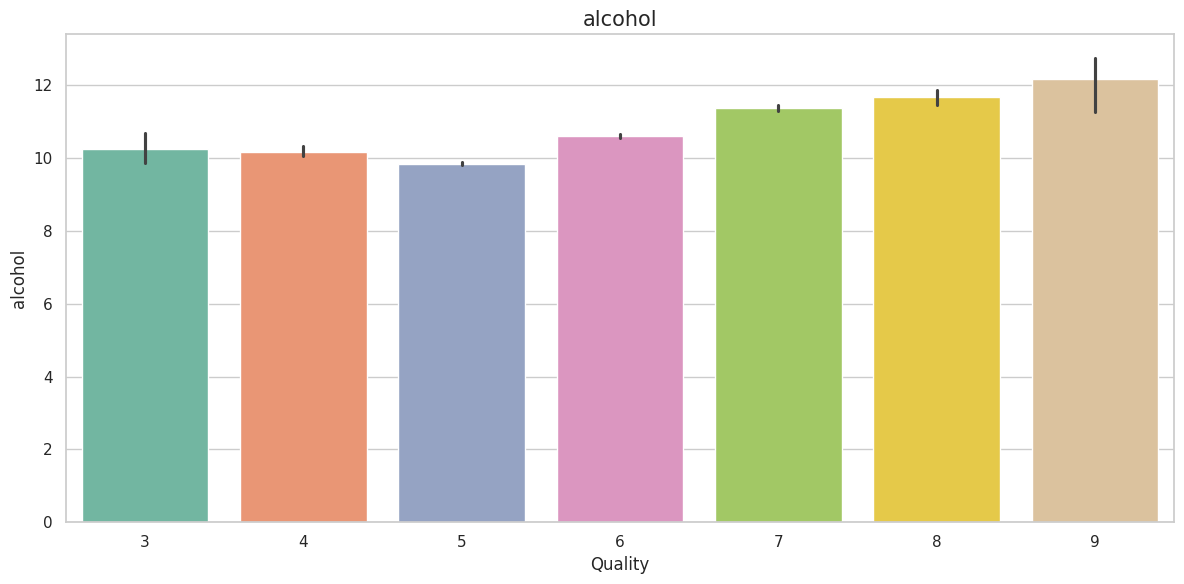

In [16]:
# train에서 각 변수와 quality 변수 사이 분포를 확인합시다

sns.set(style="whitegrid") # 배경 깔끔하게

for i in range(11):
  plt.figure(figsize  = (12,6))

  sns.barplot(
      x = 'quality',
      y = train.columns[i+2],
      data = train,
      palette = 'Set2' # 컬러풀하게
  )


  plt.title(train.columns[i+2], fontsize=15)
  plt.xlabel('Quality', fontsize=12)
  plt.ylabel(train.columns[i+2], fontsize=12)


  plt.tight_layout()
  plt.show()

데이터 전처리

In [51]:
# type에는 white와 red 두 종류가 있습니다
# 각각 0,1로 변환합니다.

enc = LabelEncoder()
enc.fit(train['type'])
train['type'] = enc.transform(train['type'])
test['type'] = enc.transform(test['type'])

In [20]:
train.head()

,index,quality,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type
0,0,5,5.6,0.695,0.06,6.8,0.042,9.0,84.0,0.99432,3.44,0.44,10.2,1
1,1,5,8.8,0.610,0.14,2.4,0.067,10.0,42.0,0.99690,3.19,0.59,9.5,0
2,2,5,7.9,0.210,0.39,2.0,0.057,21.0,138.0,0.99176,3.05,0.52,10.9,1
3,3,6,7.0,0.210,0.31,6.0,0.046,29.0,108.0,0.99390,3.26,0.50,10.8,1
4,4,6,7.8,0.400,0.26,9.5,0.059,32.0,178.0,0.99550,3.04,0.43,10.9,1


In [21]:
# 불필요한 변수 제거
train_x = train.drop(['index', 'quality'], axis=1)
train_y = train['quality']
test_x = test.drop(['index'], axis=1)

In [22]:
train_x.shape, train_y.shape, test_x.shape

((5497, 12), (5497,), (1000, 12))

모델링 진행

In [23]:
from sklearn.ensemble import RandomForestClassifier
# 모델선언
model = RandomForestClassifier()

# 모델학습
model.fit(train_x, train_y)

RandomForestClassifier()

In [24]:
# 학습화 된 모델로 test 데이터 예측
y_pred = model.predict(test_x)

제출 파일 생성

In [27]:
submission = pd.read_csv('sample_submission.csv')
submission['quality']=y_pred
submission

,index,quality
0,0,5
1,1,6
2,2,6
3,3,5
4,4,6
...,...,...
995,995,6
996,996,5
997,997,5
998,998,6


In [28]:
# csv 파일로 저장
submission.to_csv('baseline.csv', index=False)

In [30]:
train['alcohol_density'] = train['alcohol'] / train['density']
test['alcohol_density'] = test['alcohol'] / test['density']

In [52]:
# 검증 추가

x = train.drop('quality', axis=1)
y = train['quality']

X_train, X_valid, y_train, y_valid = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [33]:
# 기존 랜덤포레스트 그대로 사용
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [34]:
# 검증 점수 확인 (중요)

pred = model.predict(X_valid)
print("Accuracy:", accuracy_score(y_valid, pred))

Accuracy: 0.6436363636363637


In [38]:
# 제출 재시도
pred_test = model.predict(test)

submission['quality'] = pred_test
submission.to_csv('submission_v2.csv', index=False)

In [40]:
# 검증 검수 먼저 확인
pred = model.predict(X_valid)
acc = accuracy_score(y_valid, pred)
print("Accuracy:", acc)

Accuracy: 0.6436363636363637


In [49]:
# 라이브러리 추가

In [42]:
X = train.drop('quality', axis=1)
y = train['quality']

In [43]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

랜덤포레스트 모델 만들기

In [44]:
rf_model = RandomForestClassifier(random_state=42)

In [45]:
# 교차검증 실행

scores = cross_val_score(rf_model, X, y, cv=skf, scoring='accuracy')

In [46]:
print("각 폴드 정확도:", scores)
print("평균 정확도:", scores.mean())

각 폴드 정확도: [0.66818182 0.66727273 0.66151046 0.67970883 0.65878071]
평균 정확도: 0.6670909090909091


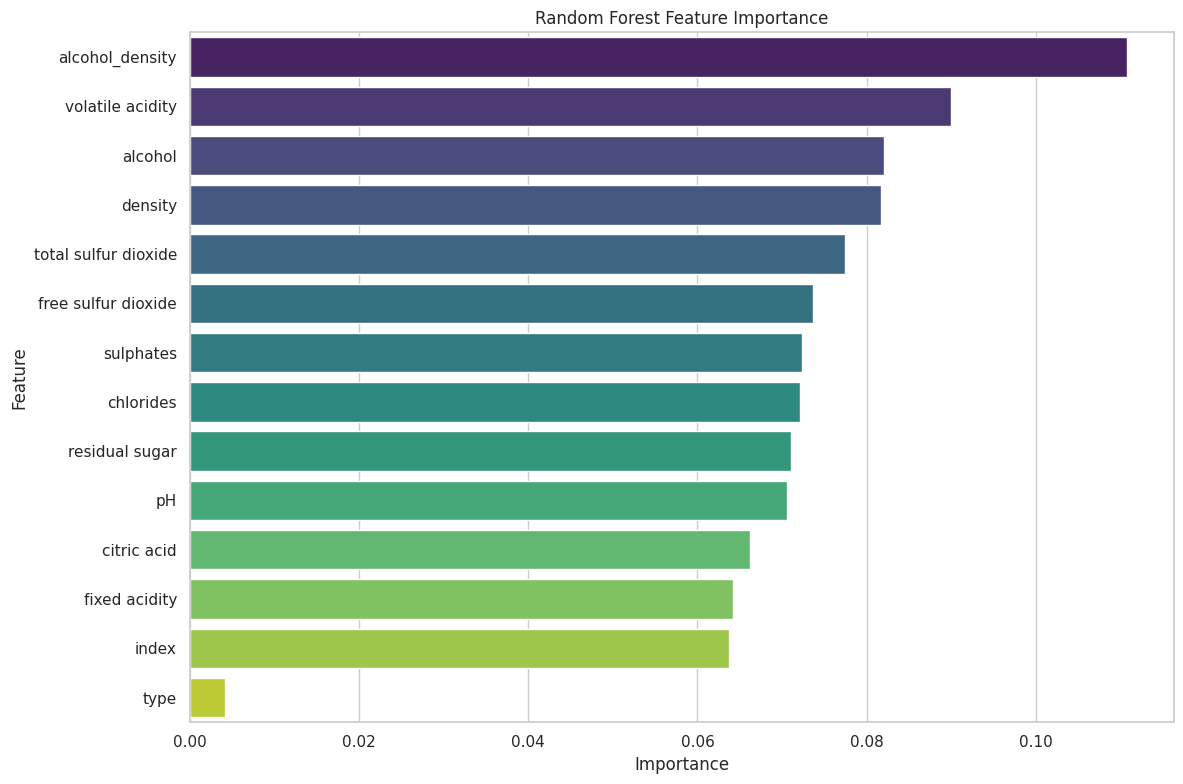

In [59]:
# 랜덤 포레스트 피처 중요도 추출
rf_feature_importances = model.feature_importances_
rf_feature_names = X_train.columns

# 피처 중요도를 데이터프레임으로 생성
rf_importance_df = pd.DataFrame({'Feature': rf_feature_names, 'Importance': rf_feature_importances})

# 중요도 순으로 정렬
rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False)

# 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=rf_importance_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

LightGBM

In [53]:
import lightgbm as lgb

### LightGBM 모델 생성 및 교차 검증

In [54]:
# LightGBM 모델 선언
lgbm_model = lgb.LGBMClassifier(random_state=42)

# 교차 검증 실행
# X와 y는 이전에 정의된 train 데이터의 피처와 타겟 변수입니다.
# skf는 이전에 정의된 StratifiedKFold 객체입니다.
scores_lgbm = cross_val_score(lgbm_model, X, y, cv=skf, scoring='accuracy')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010428 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2005
[LightGBM] [Info] Number of data points in the train set: 4397, number of used features: 14
[LightGBM] [Info] Start training from score -5.344155
[LightGBM] [Info] Start training from score -3.391465
[LightGBM] [Info] Start training from score -1.123248
[LightGBM] [Info] Start training from score -0.821849
[LightGBM] [Info] Start training from score -1.783380
[LightGBM] [Info] Start training from score -3.584657
[LightGBM] [Info] Start training from score -7.002383
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furth

In [55]:
print("각 폴드 정확도 (LightGBM):", scores_lgbm)
print("평균 정확도 (LightGBM):", scores_lgbm.mean())

각 폴드 정확도 (LightGBM): [0.63363636 0.65545455 0.65150136 0.63512284 0.62238399]
평균 정확도 (LightGBM): 0.6396198196707751


### LightGBM 모델 피처 중요도 시각화

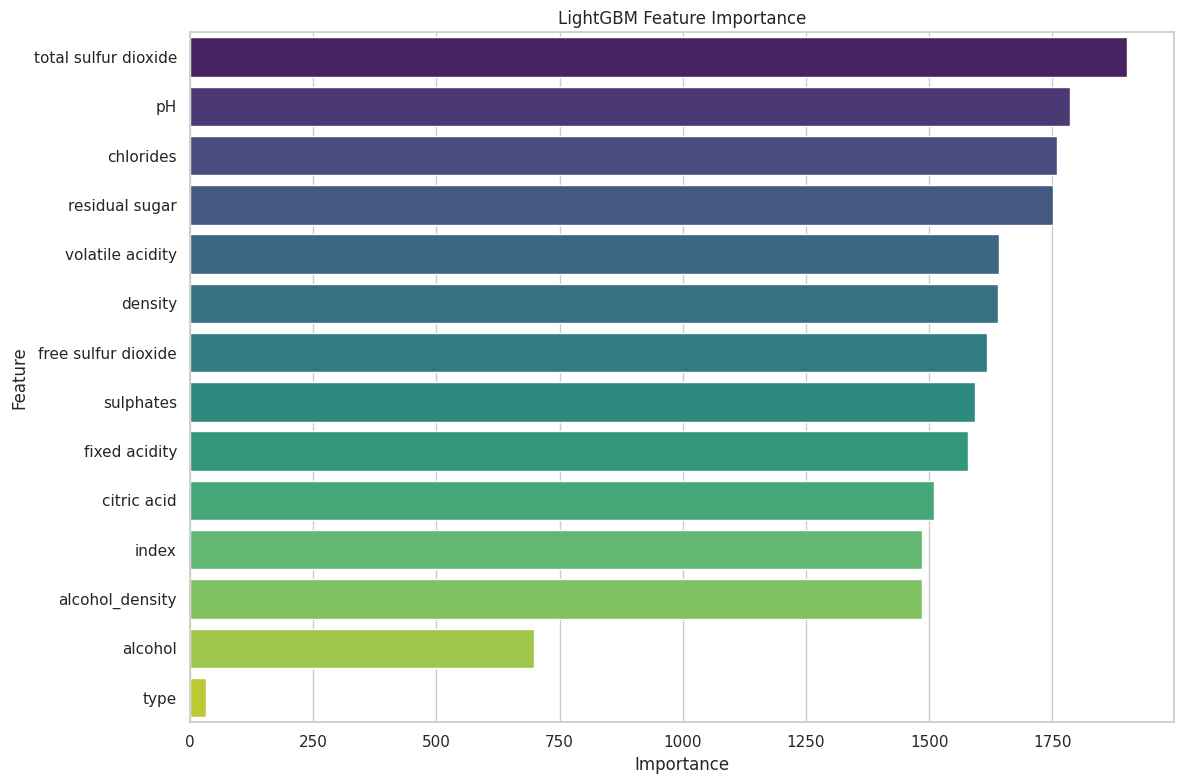

In [57]:
# 피처 중요도 추출
feature_importances = lgbm_model.feature_importances_
feature_names = X_lgbm.columns

# 피처 중요도를 데이터프레임으로 생성
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# 중요도 순으로 정렬
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('LightGBM Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Modeling

In [66]:
# Labrary
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

In [69]:
#Standardscaler
ss= StandardScaler()
numerical_columns = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'alcohol_density']
train[numerical_columns] = ss.fit_transform(train[numerical_columns])

#factorize
train['type'] = pd.factorize(train['type'])[0]

train.head(3)

,index,quality,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type,alcohol_density
0,0,5,-1.250611,2.186377,-1.78194,0.286345,-0.398500,-1.211937,-0.560852,-0.117252,1.372128,-0.605988,-0.255287,0,-0.249543
1,1,5,1.234899,1.665574,-1.23056,-0.638755,0.322998,-1.155351,-1.307080,0.738864,-0.183584,0.398147,-0.841348,1,-0.844773
2,2,5,0.535849,-0.785265,0.49250,-0.722855,0.034399,-0.532907,0.398583,-0.966732,-1.054782,-0.070450,0.330774,0,0.348602


- StandardScaler를 통해서 표준화 작업을 진행하였고,
type을 0과 1로 변환해주었습니다.
-  ML에서는 str은 들어가지 않으므로 변환은 꼭 하자
- 이외에도 encoding에는 pd.get_dummies(), labelEncoder 등이 있습니다.

In [70]:
X = train.drop(['quality'],axis=1)
y = train.quality

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2, random_state=42)

test_size : 0.2 train과 test를 8:2로 구분한다는 의미!
random_state : 42 같은 값으로 나오게 하기 위한 Seed 설정!

In [72]:
X_train.shape, X_test.shape

((4397, 14), (1100, 14))

In [76]:
def Model(model):
    model.fit(X_train,y_train)
    score = model.score(X_test,y_test)
    model_train_score= model.score(X_train,y_train)
    model_test_score=model.score(X_test,y_test)
    prediction = model.predict(X_test)
    cm = confusion_matrix(y_test, prediction)
    print("Testing Score\n", score)
    # plot_confusion_matrix(model,X_test,y_test,cmap='OrRd') # Deprecated function, removed to fix NameError

In [77]:
#RandomForest
rf= RandomForestClassifier()
rf.fit(X_train,y_train)
Model(rf)

Testing Score
 0.6718181818181819
